In [2]:
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path
import pyshtools as pysh
import pathlib as path

pygmt-session [ERROR]: Cannot find the PSL_UTF-8 encoding
begin [ERROR]: Cannot find the PSL_UTF-8 encoding
d:\conda_envs\planet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_ROOT = Path.cwd().parent

In [4]:
plt.rcParams['font.sans-serif'] = ['SimHei']      # 黑体
plt.rcParams['axes.unicode_minus'] = False        # 解决负号显示问题

月壳厚度数据

In [5]:
PROJECT_ROOT = Path.cwd().parent
data_filename=PROJECT_ROOT/"result/frequency_domain_run1.pkl"
result_filename = "moon_thickness_run1_mollweide_marked.png"

with open(data_filename, "rb") as f:
    result = pickle.load(f)

thick = result["thick_grid"].data
nlat, nlon = thick.shape

lats = np.linspace(90, -90, nlat)
lons = np.linspace(0, 360, nlon, endpoint=False)

thick_da = xr.DataArray(thick, coords=[lats, lons], dims=["lat", "lon"])
thick_da.values=thick_da.values*1e3

月球地形数据

In [6]:
topo = pysh.datasets.Moon.LDEM_shape_pa()
topo_grid = topo.expand(grid="DH2", lmax=1200, extend=False)
topo_xr = topo_grid.to_xarray()

In [24]:
def plot_equatorial(topo_xr,thick_da):
    topo_da=topo_xr.interp_like(thick_da,method="nearest")
    moho_da=topo_da-thick_da
    topo_eq = topo_da.sel(lat=0, method="nearest")
    moho_eq = moho_da.sel(lat=0, method="nearest")
    
    theta = np.deg2rad(topo_eq.lon.values)
    Rmoon = 1737.4*1e3  # km
    
    # 处理数据
    R_surface = topo_eq.values - Rmoon
    R_moho = moho_eq.values - Rmoon

    # 处理 NaN
    mask = np.isfinite(R_surface) & np.isfinite(R_moho)
    theta_plot = theta[mask]
    R_surface_plot = R_surface[mask]
    R_moho_plot = R_moho[mask]

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 15,
        "axes.linewidth": 1,
    })

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, projection="polar")

    # ----------------------
    # mantle 填充
    # ----------------------
    rmin = np.nanmin(R_moho_plot)
    ax.fill_between(theta_plot, rmin, R_moho_plot, color="0.92", zorder=0)

    # ----------------------
    # crust 按区间填充
    # 分界线：3°E, 100°E, 55°W(305°E)
    # ----------------------
    boundaries_deg = [3, 100, 295]
    boundaries_deg = np.array(boundaries_deg)

    # 定义区间
    regions = [
        (295, 360),
        (0, 3),
        (3, 100),
        (100, 295)
    ]

    # 颜色，每个区间不同
    colors = ["#E6AB02", "#E6AB02", "#1B9E77", "#7570B3"]

    # 填充
    for (lon0, lon1), color in zip(regions, colors):
        t0 = np.deg2rad(lon0)
        t1 = np.deg2rad(lon1)
        if t1 < t0:  # 跨 0°
            mask_region = (theta_plot >= t0) | (theta_plot < t1)
        else:
            mask_region = (theta_plot >= t0) & (theta_plot < t1)
        ax.fill_between(
            theta_plot[mask_region],
            R_moho_plot[mask_region],
            R_surface_plot[mask_region],
            color=color,
            alpha=0.8,
            zorder=1
        )

    # ----------------------
    # Moho & surface 线
    # ----------------------
    ax.plot(theta_plot, R_surface_plot, color="black", lw=1.8, label="表面", zorder=3)
    ax.plot(theta_plot, R_moho_plot, color="0.35", lw=1.5, label="莫霍面", zorder=4)

    # ----------------------
    # 分界线
    # ----------------------
    for lon in boundaries_deg:
        t = np.deg2rad(lon)
        ax.plot([t, t], [np.nanmin(R_moho_plot), np.nanmax(R_surface_plot)],
                color="black", lw=1.2, zorder=5)

    # ----------------------
    # 极坐标设置
    # ----------------------
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_thetagrids([0,45,90,135,180,225,270,315],
                    labels=["0°","45°E","90°E","135°E","180°","135°W","90°W","45°W"])
    ax.spines['polar'].set_visible(False)

    # 半径范围
    ax.set_rlim(-150*1e3, 15*1e3)

    # 径向刻度
    r_ticks = np.arange(-100e3, 20e3, 50e3)
    ax.set_rticks(r_ticks)
    ax.set_yticklabels([f"{int(r/1000)} km" for r in r_ticks])
    ax.set_rlabel_position(135)

    # 图例
    #ax.legend(frameon=False, loc="upper right")


    plt.tight_layout()
    plt.show()
    
    return fig

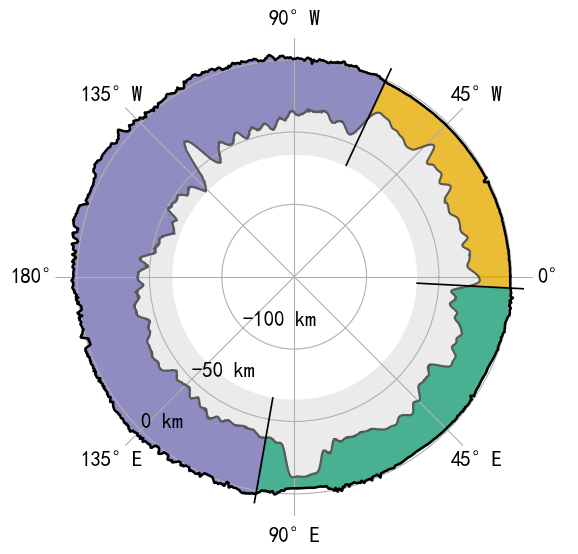

In [25]:
fig=plot_equatorial(topo_xr,thick_da)

In [26]:
fig.savefig(PROJECT_ROOT/"plotting/figure/球谐域_赤道剖面图.png",dpi=600)